In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.instrument.rubin import RubinObservatory
from scipy.optimize import minimize
import numpy as np
import cosmographi as cp
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun
from cosmographi.utils.flux import convert_to_jy
jax.config.update("jax_enable_x64", True)


ERROR:2026-08-12 14:27:06,485:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [2]:
import numpy as np
import jax.numpy as jnp
import os
import jax

jax.config.update("jax_enable_x64", True)

os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import matplotlib.pyplot as plt



def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0, seed: int | None = None):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    rng = np.random.default_rng(seed=seed)
    white_noise = rng.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    exp = jnp.exp(colored_noise)
    return exp / jnp.mean(exp)

In [3]:
# plt.scatter(range(1000), generate_perturbations_vector(0.5, 1000))
# plt.axhline(1, color="red")
# plt.show()




# sizes = [100, 1000, 10000]
# alpha = 0.9

# a = []
# for size in sizes:
#     avs = []
#     for _ in range(1000):
#         s = generate_perturbations_vector(alpha, size)
#         avg = jnp.mean(s)
#         if avg > 100:
#             plt.plot(s)
#             plt.show()
#         avs.append(avg)
#     a.append(avs)
# a = np.asarray(a)
# sa = np.mean(a[0])
# sb = np.mean(a[1])
# sc = np.mean(a[2])

# plt.scatter(sizes, [sa, sb, sc])
# plt.xscale("log")
# plt.show()

# print(sa)
# print(np.median(a[0]))
# print(sb)
# print(np.median(a[1]))
# print(sc)
# print(np.median(a[2]))

# print(f"final mean: {np.mean([sa, sb, sc])}")
# plt.scatter(sizes, a[:, 1])
# plt.xscale("log")
# plt.axhline(sb)
# plt.show()
# plt.scatter(sizes, a[:, 2])
# plt.xscale("log")
# plt.axhline(sc)
# plt.show()

# sepparation

In [4]:
from cosmographi.utils.constants import c_nm
from cosmographi.utils.flux import f_nu

def compute_neg_log_likelihood(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time, end_time = (times[0], times[-1])
    if len(x) == 2:
        proposed_alpha, num_perturbation_samples = x
    else:
        proposed_alpha, num_perturbation_samples, noise_var = x
    num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
    sample_rate = num_perturbation_samples / (end_time - start_time)
    perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    key = jax.random.key(42)
    agn.t0 = start_time
    C = cp.cosmology.Cosmology()
    agn.z = z
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
    def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
    band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
    band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
    zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
    model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
    model_flux_comparable_units = model_flux_jansky * 1e9
    n = len(observed_flux)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return float(ll)


def minimize_log_likelihood(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    if noise_var is None:
        bounds = [(0.0, 2.0), (2.0, None), (1e-12, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times), 3])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    else:
        bounds = [(0.0, 2.0), (2.0, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times)])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    return results


In [5]:
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd

passband_group = PassbandGroup.from_preset(preset="LSST")
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)

# Draw redshift from the uniform distribution
redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# Draw decimal logarithm of the black hole mass (in solar masses)
# from the uniform distribution
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# Transform to mass in solar masses
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
# Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# First, we define a PDF function, for "blue" galaxies, see
# https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

# We use a special random node to sample from this PDF
edd_ratio = SamplePDF(edd_ratio_pdf)
# We use a special distribution to draw positions from the survey coverage area
radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    # Reference time is not important for a stochastic model
    t0=obstable.time_bounds()[0],  # reference date, the survey start
    blackhole_mass=bh_mass,  # black hole mass in solar masses
    edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
    redshift=redshift,
    ra=radec.ra,
    dec=radec.dec,
    cosmology=Planck18,
    inclination=0
)

# Make it reproducible
rng = np.random.default_rng(42)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

df = simulate_lightcurves(
    model=model,
    num_samples=1,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio",
    ],
    rng=rng,
)
# params is too large to show =)


/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Simulating: 100%|██████████| 1/1 [00:00<00:00,  2.35obj/s]


In [6]:
SECS_IN_YEAR = 31536000
data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])

lc = df.loc[0, "lightcurve"]
obs_idx = jnp.asarray(lc["obs_idx"])
obs_t = jnp.asarray(obstable["time"].iloc[obs_idx])
exp_times = jnp.asarray(obstable["exptime"].iloc[obs_idx])
sky_brightnesses = jnp.asarray(obstable["skybrightness"].iloc[obs_idx])
filters = obstable["filter"].iloc[obs_idx].to_numpy()
times = obs_t
flux = data[:, 1]
bh_mass = 10**df.loc[0,'bh_mass_lg_mass'] * M_sun
edd_ratio = df.loc[0, 'AGN_0_edd_ratio']
redshift = df.loc[0, 'z']
critical_accretion_rate = 1.4e18 * (bh_mass / M_sun)
accretion_rate = edd_ratio * SECS_IN_YEAR * critical_accretion_rate /1000
pixel_scale = obstable.survey_values["pixel_scale"]
PSF_Aeffs = (obstable["psf_footprint"].iloc[obs_idx].to_numpy()* pixel_scale**2)




In [7]:
results = minimize_log_likelihood(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=1)

In [8]:
assert np.all(data[:, 0]==obs_t)

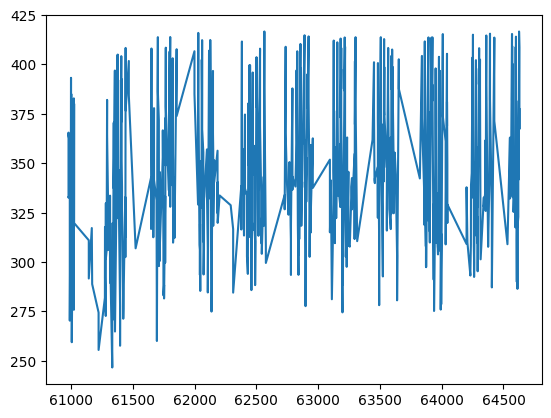

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 467491815.08995515
       x: [ 2.693e-01  4.804e+00]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 68


In [9]:
plt.plot(times, flux)
plt.show()

print(results)

In [10]:
# from cosmographi.source import TransientSource
# import os
# from caskade import Param, forward
# from cosmographi.cosmology import Cosmology
# from cosmographi.source import TransientSource
# import numpy as np
# from cosmographi.utils.constants import c_nm, c_cm, c_m, G, h_m2kg, me_g, k, h, k_si
# from cosmographi.utils.integration import quad
# from cosmographi.source.func import integrand_funct, slim_disk_corona_integrand_funct, F, compute_T0, standard_disk_integration_f
# from jax.scipy.integrate import trapezoid
# from cosmographi.utils.flux import f_l

# PARSECS_TO_METRES = 3.086e+16
# ABSOLUTE_FLUX_TO_LUM_DENSITY = (10 * 3.086e+18) **2 * jnp.pi * 4
# SECS_IN_YEAR = 31536000
# KG_TO_G = 1e3
# M_sun = 1.9891e30

# class AGNSourceLipunova2018(TransientSource):
#     """ Create an AGN source whose SED is modelled according to the standard disk model, as used in lighcurvelynx, based on https://doi.org/10.1007/978-3-319-93009-1_1

#     Parameters
#     ---------- 
#     cosmology: Cosmology. 
#         Optional. If given, it can be used to compute the distance modulus from the redshift.
#     name: str. 
#         Optional. Name of the source.
#     blackhole_mass: float. 
#         Mass of the black hole in kg
#     accretion_rate: float. 
#         Accretion rate of the black hole, in kg/year
#     inclination_angle: Param(float)
#         Inclination angle of the AGN with respect to the observer. The oberver's line of sight makes an angle i 
#         to the normal to the disc plane. In radians. 
#     r_rin_to_rngin: Param(float)
#         Ratio of the inner radius to the gravitational radius of the black hole. 
#     times: jnp.ndarray[float] | None
#         A vector of length equal to <time_perturbations> whose values equal to the times represented by <time_perturbations>.
#     time_perturbations: jnp.ndarray[float] | None
#         An array containing all of the values the base luminosities will be multiplied by to cause variability with respect to time. 
#         Its length will determine the number of timepoints we will have in the grid. 
#     """
#     name: str
#     cosmology: Cosmology
#     blackhole_mass: float 
#     accretion_rate: float
#     inclination_angle: float
#     rin_to_rng: float
#     times: jnp.ndarray
#     perturbations: jnp.ndarray

#     def __init__(self, cosmology: Cosmology = None, name: str = None, blackhole_mass: float = None, accretion_rate: float = None, inclination_angle: float = None, 
#                  rin_to_rng: float = 6, perturbations_ar: jnp.ndarray = None, start_time: float = None, end_time: float = None, **kwargs) -> None:
#         super().__init__(cosmology=cosmology, name=name, **kwargs)
#         self.blackhole_mass = Param("blackhole_mass", blackhole_mass, shape=(), 
#                                    description="Mass of the black hole", units="kg")
#         self.accretion_rate = Param("accretion_rate", accretion_rate, shape=(), 
#                                    description="accretion_rate of the black hole", units="kg/year")
#         self.inclination_angle = Param("inclination_angle", inclination_angle, units="radians", description="inclination angle of the AGN with respect to the observer")
#         self.rin_to_rng = Param("rin_to_rng", rin_to_rng, units="dimentionless", description="inner radius of the thin disk")
#         self.perturbations = Param("perturbations", perturbations_ar, units="dimentionless", shape=(len(perturbations_ar), ), description="a vector containing all of the numbers the base luminosities will be " \
#         "multiplied by. Cause the variability with respect to time. Its length will determine the number of time points queried.")
#         self.times = jnp.linspace(start_time, end_time, len(perturbations_ar))
    
#     @forward
#     def base_luminosity_density(self, w: float | jnp.ndarray, num_integration_points: int = 100, inclination_angle=None, blackhole_mass=None, accretion_rate=None, rin_to_rng=None) -> float:
#         """ Calculate the time-indepenedent base luminosity density predicted by the thin disk model for this AGN. Return in erg/s/nm. w must be in nm, and the distance <d> in parsecs."""
#         w = jnp.atleast_1d(w)
#         freq = c_nm/w
#         r_in = rin_to_rng * G * blackhole_mass / c_m**2 # in metres
#         r_0 = (7 / 6) ** 2 * r_in # as done in lighcurvelynx from page 31 of https://doi.org/10.1007/978-3-319-93009-1_1
#         T_0 = compute_T0(blackhole_mass, accretion_rate, r_in)
#         distance = 10 * PARSECS_TO_METRES
#         # Set minimum x_in value for numerical stability
#         x_in = jnp.maximum(h_m2kg * freq / (k_si * T_0) * (r_in / r_0) ** (3 / 4), 1e-6)
#         x_out = x_in + 100
#         # def _ (a, b):
#         #     return quad(standard_disk_integration_f, a=a, b=b, n=num_integration_points)
#         # integral = jax.vmap(_)(x_in, x_out)
#         integral = jax.vmap(quad, in_axes=(None, 0, 0, None))(standard_disk_integration_f, x_in, x_out, num_integration_points)
#         flux_freq = 16 * jnp.pi / 3 / distance**2 * jnp.cos(inclination_angle) * (k_si * T_0 / h_m2kg)**(8/3) * h_m2kg * freq**(1/3) * r_0**2 / (c_m**2) * integral * 10**3 # erg/s/cm^2/Hz
#         flux = f_l(f_nu=flux_freq, nu =freq)
#         luminosity_density = flux * ABSOLUTE_FLUX_TO_LUM_DENSITY
#         return luminosity_density

#     @forward
#     def luminosity_density(self, w: jnp.ndarray, t: jnp.ndarray, integration_points: int = 100, perturbations=None) -> jnp.ndarray:
#         """ Interpolate the luminosity density ( erg/s/nm ) for a all combinations of the elements in <w> and <t>."""
#         t = jnp.atleast_1d(t)
#         base_luminosity = self.base_luminosity_density(w=w, num_integration_points=integration_points)
#         perturbation = jnp.interp(t, self.times, perturbations) # linearly interpolate perturbations
#         perturbation = perturbation
#         return base_luminosity[None, :] * perturbation[:, None]

In [11]:
# proposed_alpha, num_perturbation_samples =  2.675e-01, 4.842e+00
proposed_alpha, num_perturbation_samples =  2.693e-01,  4.804e+00
# proposed_alpha, num_perturbation_samples =  2.675e-01, 48.42e+00
start_time, end_time = (times[0], times[-1])
num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
sample_rate = num_perturbation_samples / (end_time - start_time)
perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
print(np.mean(perturbations))
agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
agn.t0 = start_time
C = cp.cosmology.Cosmology()
agn.z = redshift
agn.cosmology = C
agn.mu = agn.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn.get_values())
print(source_values)
survey_values = jnp.asarray(rubin.get_values())    
print(survey_values)
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
my_model_flux = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn, times, source_values, survey_values)[2]
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
my_model_flux_jansky = convert_to_jy(my_model_flux, band, zero_points, rubin.effective_aperture)
my_model_flux_comparable_units = my_model_flux_jansky * 1e9

1.0
[7.27631226e-01 4.33088197e+01 6.09800253e+04]
[1.2]


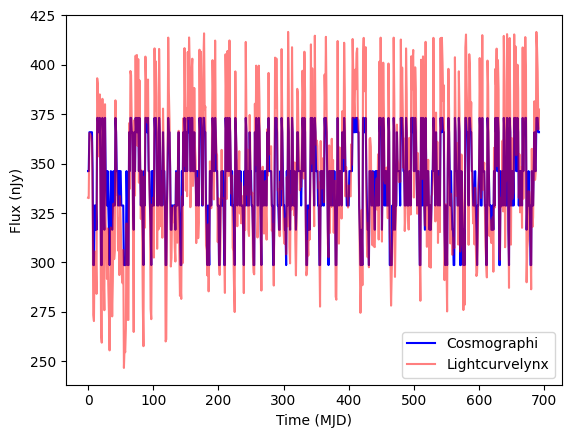

342.12464646534755
343.6964473616971
[6.36366146e-05]


In [12]:
plt.plot(my_model_flux_comparable_units, color="blue", label="Cosmographi")
plt.plot(flux, color='red', label="Lightcurvelynx", alpha=0.5)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux (nJy)")
plt.legend()
plt.show()

print(np.mean(my_model_flux_comparable_units))
print(np.mean(flux))

print(my_model_flux[0])

In [13]:
# perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, seed=42)
# agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
#                                 start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
# rubin = RubinObservatory()
# rubin.throughput.trim()
# rubin.throughput.to_dynamic() 
# band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
# key = jax.random.key(42)
# t_range = (jnp.min(times), jnp.max(times))
# source_t = np.random.uniform(*t_range)
#     agn.t0 = source_t
#     C = cp.cosmology.Cosmology()
#     agn.z = z
#     agn.cosmology = C
#     agn.mu = agn.cosmology.distance_modulus(source_z)
#     source_values = jnp.asarray(agn.get_values())
#     survey_values = jnp.asarray(rubin.get_values())    
#     obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
#     model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[0]

# Trying to make a DRW w/ Tiny GP

In [2]:
from tinygp import GaussianProcess, kernels
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


def build_gp(theta: tuple[float], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale, log_noise) parameters.
    """
    log_sigma, log_scale, log_noise = theta
    kernel = kernels.stationary.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=jnp.exp(log_noise)**2)



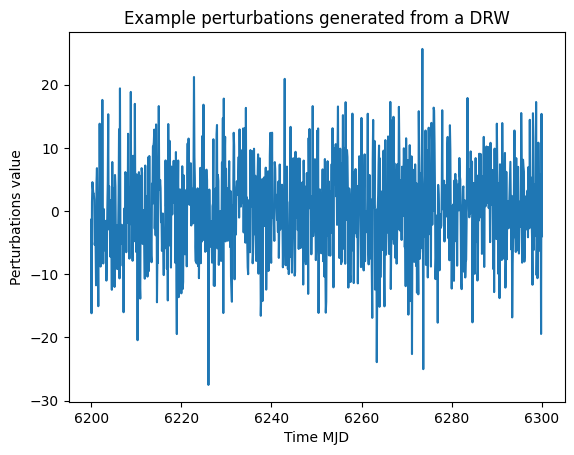

In [5]:
scale = -10.2
noise = 2
theta = (scale, noise)
x = jnp.linspace(6200, 6300, 1000)
kernel = kernels.stationary.Exp(scale=jnp.exp(scale))
gp = GaussianProcess(kernel, x, diag=jnp.exp(noise)**2)
key = jax.random.key(42)
samples = gp.sample(key)
plt.plot(x, samples)
plt.xlabel("Time MJD")
plt.ylabel("Perturbations value")
plt.title("Example perturbations generated from a DRW")
plt.show()

In [16]:
def generate_perturbations_gp(scale: float, noise: float, num_samples: int, key = None) -> jnp.ndarray:
    x = jnp.arange(num_samples)
    kernel = kernels.stationary.Exp(scale=jnp.exp(scale))
    gp = GaussianProcess(kernel, x, diag=jnp.exp(noise)**2)
    samples = gp.sample(key)
    return jnp.exp(samples) / jnp.mean(samples)

key = jax.random.key(42)
print(generate_perturbations_gp(2, 0.5, 9, key))


[-0.21986504 -0.05597584 -0.31976319 -0.25816506 -0.03268624 -0.25985029
 -0.2425406  -8.33316389 -0.02466709]


In [17]:
def compute_neg_log_likelihood_gp(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time, end_time = (times[0], times[-1])
    scale, noise, num_perturbation_samples = x
    num_perturbation_samples = 1000
    key = jax.random.key(42)
    perturbations = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    key = jax.random.key(42)
    agn.t0 = start_time
    C = cp.cosmology.Cosmology()
    agn.z = z
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
    def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
    band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
    band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
    zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
    model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
    model_flux_comparable_units = model_flux_jansky * 1e9
    n = len(observed_flux)
    print(noise_var)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return ll.item()


def minimize_log_likelihood_gp(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
    x0 = np.asarray([100, 10, times[-1] - times[0]])
    results = minimize(compute_neg_log_likelihood_gp, x0, args, method="Powell")
    return results


In [18]:
results_gp = minimize_log_likelihood_gp(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=jnp.var(flux))

print(results_gp)

1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858
1438.4638218359858


KeyboardInterrupt: 

[-0.0000000e+000            -inf -1.0350315e+277 ... -0.0000000e+000
            -inf            -inf]
[3.48457475e-01 1.08303438e-02 1.83191326e+00 2.80804025e+00
 7.58668803e-04]
[-0.0000000e+000            -inf -1.0350315e+277 ... -0.0000000e+000
            -inf            -inf]
[-0.0000000e+000            -inf -1.0350315e+277 ... -0.0000000e+000
            -inf            -inf]
[6.36366146e-05]
[0.]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0

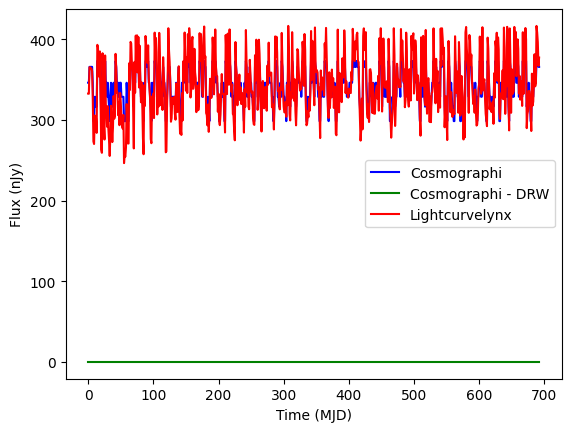

In [ ]:
scale, noise, num_samples = 1.000e+02, 1.000e+01, 3.649e+03
start_time, end_time = (times[0], times[-1])
num_perturbation_samples = max(int(round(num_samples)), 2)
key = jax.random.key(42)

perturbations2 = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)

agn2 = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar = perturbations2, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
print(agn2.perturbations.value)
print(perturbations)
print(perturbations2)

rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
agn2.t0 = start_time
C = cp.cosmology.Cosmology()
agn2.z = redshift
agn2.cosmology = C
agn2.mu = agn2.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn2.get_values())
survey_values = jnp.asarray(rubin.get_values())  
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
print(agn2.perturbations.value)
model_flux2 = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn2, times, source_values, survey_values)[2]
print(my_model_flux[0])
print(model_flux2[0])
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
model_flux_jansky2 = convert_to_jy(model_flux2, band, zero_points, rubin.effective_aperture)
model_flux_comparable_units2 = model_flux_jansky2 * 1e9
print(model_flux_comparable_units2)
plt.plot(my_model_flux_comparable_units, color="blue", label="Cosmographi")
plt.plot(model_flux_comparable_units2, color="green", label="Cosmographi - DRW")
plt.plot(flux, color='red', label="Lightcurvelynx")
plt.xlabel("Time (MJD)")
plt.ylabel("Flux (nJy)")
plt.legend()
plt.show()



In [ ]:
out = rubin.observe(
    key,
    band[0],
    exp_times[0],
    sky_brightnesses[0],
    PSF_Aeffs[0],
    agn2,
    times[0],
    source_values,
    survey_values,
)
print(out[2])

[0.]


In [ ]:
print(np.allclose(perturbations, perturbations2))

ValueError: operands could not be broadcast together with shapes (5,) (3649,) 